In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#df = pd.read_csv(r"C:\Users\S\Datasets.csv")
df = pd.read_csv("FInal_aggregated_dataset.csv")

In [3]:
df = df.drop(columns=["Newsenti","Tweetsenti","vol_1"], errors="ignore")

In [4]:
df.columns

Index(['Date', 'index', 'volatility', 'Newscore', 'Tweetscore',
       'garch_volatility'],
      dtype='object')

In [5]:
df = df.sort_values(by='Date').reset_index(drop=True)

Y = df['volatility']
X = df.drop(columns=['volatility'])
# Add lag features (VERY IMPORTANT for time series)
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()
X = data.drop(columns=["Date",'volatility', "garch_volatility"])
Y = data['volatility']

In [6]:
split = int(0.8 * len(X))

X_train = X.iloc[:split]
X_test = X.iloc[split:]
Y_train = Y.iloc[:split]
Y_test = Y.iloc[split:]

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, Y_train)
preds = model.predict(X_test)

In [9]:
rmse = np.sqrt(mean_squared_error(Y_test, preds))
mae = mean_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -4.158062656195609
RMSE: 0.08744407246558236
MAE: 0.07168270857699242


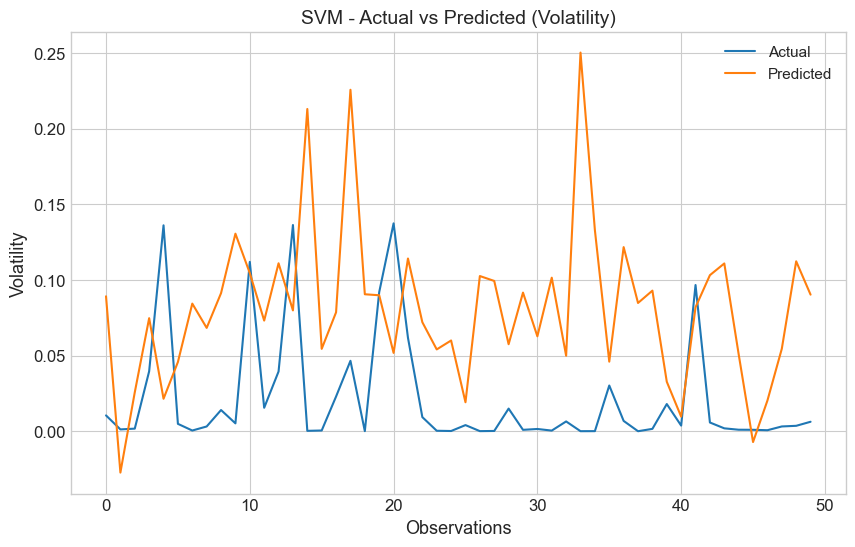

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({"font.size": 12,"figure.figsize": (10, 6),"axes.labelsize": 13,"axes.titlesize": 14,"legend.fontsize": 11})
plt.figure()
plt.plot(Y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("SVM - Actual vs Predicted (Volatility)")
plt.xlabel("Observations")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [11]:
X = data.drop(columns=['volatility', "garch_volatility","Date"])
Y = data['garch_volatility']

In [12]:
split = int(0.8 * len(X))
X_train = X.iloc[:split]
X_test = X.iloc[split:]
Y_train = Y.iloc[:split]
Y_test = Y.iloc[split:]

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, Y_train)
preds = model.predict(X_test)

In [15]:
rmse = np.sqrt(mean_squared_error(Y_test, preds))
mae = mean_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -0.08879852972091795
RMSE: 3.18956967189653
MAE: 1.9278150856925749


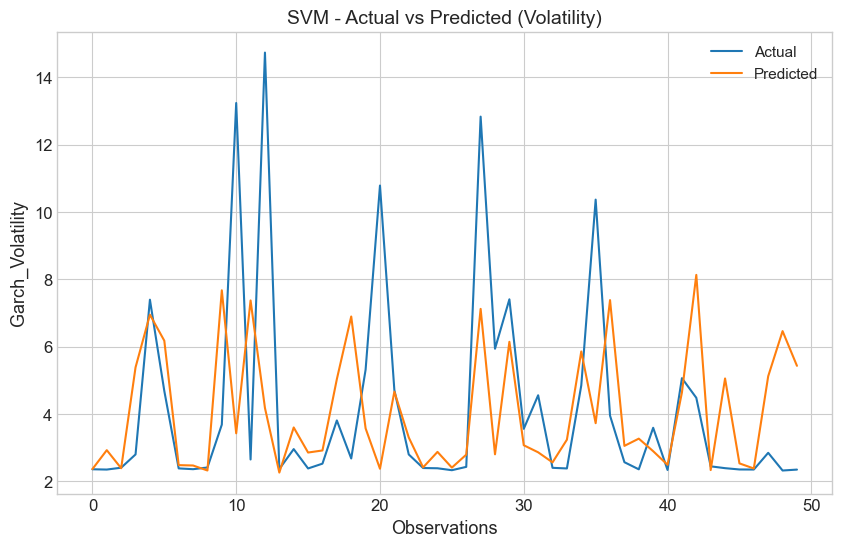

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look
plt.rcParams.update({"font.size": 12,"figure.figsize": (10, 6),"axes.labelsize": 13,"axes.titlesize": 14,"legend.fontsize": 11})
plt.figure()
plt.plot(Y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("SVM - Actual vs Predicted (Volatility)")
plt.xlabel("Observations")
plt.ylabel("Garch_Volatility")
plt.legend()
plt.show()

In [17]:
n = len(X)
splits = [int(0.80 * n),int(0.85 * n),int(0.90 * n),int(0.95 * n)]

In [18]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    # --- Scaling (fit ONLY on train) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- SVM Model ---
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

    model.fit(X_train_scaled, Y_train)

    preds = model.predict(X_test_scaled)

    # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction = np.sign(actual_diff) == np.sign(pred_diff)
    da = np.mean(direction)

    results.append({"Split": i+1,"Train Size": split,"Test Size": len(Y_test),"MSE": mse,"MAE": mae,"R2": r2,"Directional Accuracy": da})
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {da:.4f}
    """)


    Split 1
    Train Size: 198
    Test Size: 50
    MSE: 10.1734
    MAE: 1.9278
    R2: -0.0888
    Directional Accuracy: 0.6600
    

    Split 2
    Train Size: 210
    Test Size: 38
    MSE: 9.3316
    MAE: 1.8575
    R2: -0.0116
    Directional Accuracy: 0.6316
    

    Split 3
    Train Size: 223
    Test Size: 25
    MSE: 6.1024
    MAE: 1.6829
    R2: 0.1125
    Directional Accuracy: 0.5600
    

    Split 4
    Train Size: 235
    Test Size: 13
    MSE: 3.6758
    MAE: 1.3854
    R2: -3.7372
    Directional Accuracy: 0.5385
    


In [19]:
results_df = pd.DataFrame(results)
print(results_df)

   Split  Train Size  Test Size        MSE       MAE        R2  \
0      1         198         50  10.173355  1.927815 -0.088799   
1      2         210         38   9.331590  1.857452 -0.011598   
2      3         223         25   6.102421  1.682896  0.112522   
3      4         235         13   3.675844  1.385386 -3.737170   

   Directional Accuracy  
0              0.660000  
1              0.631579  
2              0.560000  
3              0.538462  


In [21]:
df = df.sort_values(by='Date').reset_index(drop=True)

Y = df['garch_volatility']
X = df.drop(columns=['garch_volatility', 'Date'])
# Add lag features (VERY IMPORTANT for time series)
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)
# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()

X = data.drop(columns=['garch_volatility'])
Y = data['garch_volatility']

In [22]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    # --- Scaling (fit ONLY on train) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- SVM Model ---
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

    model.fit(X_train_scaled, Y_train)

    preds = model.predict(X_test_scaled)

    # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction = np.sign(actual_diff) == np.sign(pred_diff)
    da = np.mean(direction)

    results.append({"Split": i+1,"Train Size": split,"Test Size": len(Y_test),"MSE": mse,"MAE": mae,"R2": r2,"Directional Accuracy": da})

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {da:.4f}
    """)


    Split 1
    Train Size: 198
    Test Size: 50
    MSE: 8.3643
    MAE: 1.7157
    R2: 0.1048
    Directional Accuracy: 0.6400
    

    Split 2
    Train Size: 210
    Test Size: 38
    MSE: 8.1867
    MAE: 1.6507
    R2: 0.1125
    Directional Accuracy: 0.6579
    

    Split 3
    Train Size: 223
    Test Size: 25
    MSE: 5.4767
    MAE: 1.4015
    R2: 0.2035
    Directional Accuracy: 0.5600
    

    Split 4
    Train Size: 235
    Test Size: 13
    MSE: 1.2930
    MAE: 0.8338
    R2: -0.6663
    Directional Accuracy: 0.6154
    


In [24]:
results_df = pd.DataFrame(results)

print(results_df)

   Split  Train Size  Test Size       MSE       MAE        R2  \
0      1         198         50  8.364298  1.715737  0.104815   
1      2         210         38  8.186718  1.650655  0.112512   
2      3         223         25  5.476745  1.401542  0.203515   
3      4         235         13  1.292994  0.833789 -0.666320   

   Directional Accuracy  
0              0.640000  
1              0.657895  
2              0.560000  
3              0.615385  
